In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2026-03-17 15:20:32.704537: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/home/admin1/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3)

2026-03-17 15:21:08.841397: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8772 - loss: 0.4316
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9641 - loss: 0.1184
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9756 - loss: 0.0807


In [9]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

  2/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0182   

2026-03-17 15:21:34.553907: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.0956
Test Accuracy: 0.9722999930381775


### Adversial attack

In [13]:
image = x_test[0]
label = y_test[0]

noise = np.random.normal(0, 0.1, image.shape)
adversarial_image = image + noise
adversarial_image = np.clip(adversarial_image, 0, 1)

In [15]:
original_pred = model.predict(image.reshape(1,28,28))
adv_pred = model.predict(adversarial_image.reshape(1,28,28))

print("Original Prediction:", np.argmax(original_pred))
print("Adversarial Prediction:", np.argmax(adv_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Original Prediction: 7
Adversarial Prediction: 7


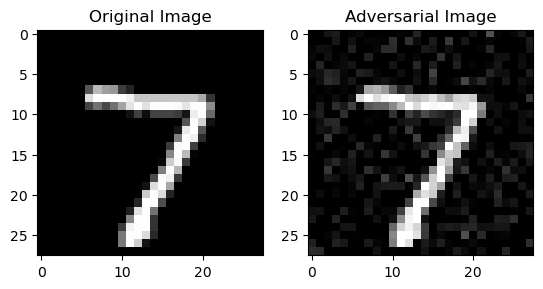

In [17]:
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")

plt.subplot(1,2,2)
plt.title("Adversarial Image")
plt.imshow(adversarial_image, cmap="gray")

plt.show()